<a href="https://colab.research.google.com/github/prangancode/lane-detection-using-semantic-models-for-bd-complex-road-scenarios/blob/main/YOLOP_lane_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mount Google Drive

This section connects our Google Colab notebook with our Google Drive. By mounting the Drive, we can seamlessly access datasets, save model checkpoints, and store logs for persistent usage.

### Why Mount Google Drive?
- 📂 **Access Large Datasets**: Directly use datasets stored in your Drive.
- 💾 **Save Model Checkpoints**: Save training progress to reload later.
- 📝 **Persistent Storage**: Keep results and logs available after the session ends.

### What Happens Here?
1. **Authentication**: we'll be prompted to authenticate with your Google account.
2. **Drive Mounting**: Drive will be mounted at `/content/drive`.
3. **File Access**: All files and directories in your Drive become accessible within this environment.

In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


# Python libraries


This section includes all the necessary libraries required for building and training a lane detection model. Below is a breakdown of their purposes:

### Core Libraries
- `os`, `json`: For file handling and dataset management.
- `cv2`: OpenCV for image processing tasks.
- `numpy`: For numerical operations and array manipulation.

### PyTorch Libraries
- `torch`, `torch.nn`: Core PyTorch framework for deep learning and defining neural networks.
- `torch.optim`: For optimization algorithms (e.g., SGD, Adam).
- `torch.utils.data`: For creating custom datasets and managing data loading.

### Data Augmentation
- `albumentations`: A powerful library for augmenting images with transformations like flipping, scaling, and rotation.
- `albumentations.pytorch`: To seamlessly convert augmented images to PyTorch tensors.

### Visualization and Progress Tracking
- `tqdm`: For displaying progress bars during data loading and training.

In [ ]:
import os
import json
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm import tqdm



import albumentations as A
from albumentations.pytorch import ToTensorV2

/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.0 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


# YOLOP Model initialization

In this section, we initialize the **YOLOP model** for lane detection. The required dependencies are installed, and the model is loaded and prepared for use on the appropriate device.

### What’s Happening Here?
1. **Installing Requirements**:
   - Install the necessary libraries specified in the YOLOP GitHub repository, including PyTorch and other dependencies.

2. **Device Selection**:
   - Automatically detect if a **CUDA-compatible GPU** is available.
   - Default to **CPU** if no GPU is detected.

3. **Model Loading**:
   - Load the **pre-trained YOLOP model** using `torch.hub`.
   - Move the model to the selected device (CPU or GPU) for efficient computation.

### Subsections
- **Install Necessary Libraries**: Use `pip` to install the required dependencies.
- **Define the Device**: Dynamically select GPU or CPU for running the model.
- **Load the YOLOP Model**: Load the model and prepare it for inference.



In [ ]:
!pip install -qr https://raw.githubusercontent.com/hustvl/YOLOP/main/requirements.txt

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 5.6 MB/s eta 0:00:00


In [ ]:
# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the YOLOP model
model = torch.hub.load('hustvl/yolop', 'yolop', pretrained=True)
model = model.to(device)  # Move the model to the selected device

/usr/local/lib/python3.11/dist-packages/torch/hub.py:330: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(
Downloading: "https://github.com/hustvl/yolop/zipball/main" to /root/.cache/torch/hub/main.zip
/root/.cache/torch/hub/hustvl_yolop_main/hubconf.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which w

# Paths for training, validation, and test datasets

In this section, we define the paths for **training**, **validation**, and **test datasets**, including image directories and corresponding binary mask directories. These paths are critical for loading the dataset during model training, validation, and testing.

### What’s Happening Here?
1. **Dataset Organization**:
   - The dataset is organized into separate folders for training, validation, and testing.
   - Each subset contains:
     - **Images**: Original lane images.
     - **Masks**: Corresponding binary masks representing lane lines.

2. **Path Definitions**:
   - Define paths for:
     - Training images and masks.
     - Validation images and masks.
     - Test images and masks.

3. **Purpose**:
   - These paths will be used for data loading and preprocessing steps in subsequent sections.

### Subsections
- **Training Dataset Paths**: Paths to training images and binary masks.
- **Validation Dataset Paths**: Paths to validation images and binary masks.
- **Test Dataset Paths**: Paths to test images and binary masks.

In [ ]:
train_images = '/content/drive/MyDrive/Object_Detection/traffic_sign_object_detection/Dataset/imagesLane/train'
train_masks = '/content/drive/MyDrive/Object_Detection/traffic_sign_object_detection/Dataset/masks/roboflow_train_truth_masks'

In [ ]:
val_images = '/content/drive/MyDrive/Object_Detection/traffic_sign_object_detection/Dataset/imagesLane/val'
val_masks = '/content/drive/MyDrive/Object_Detection/traffic_sign_object_detection/Dataset/masks/roboflow_val_truth_masks'

In [ ]:
test_images = '/content/drive/MyDrive/Object_Detection/traffic_sign_object_detection/Dataset/imagesLane/test'
test_masks = '/content/drive/MyDrive/Object_Detection/traffic_sign_object_detection/Dataset/masks/roboflow_test_truth_masks'

# Dataset Preparation

In this section, we define a custom PyTorch dataset class, `LaneDetectionDataset`, to handle image and mask loading for lane detection. The class is designed to integrate seamlessly with PyTorch's `DataLoader` for efficient data batching.

### What’s Happening Here?
1. **Initialization**:
   - Define the dataset's image and mask directories.
   - Optionally accept a set of transformations for data augmentation and preprocessing.

2. **Dataset Length**:
   - Implement the `__len__` method to return the total number of images in the dataset.

3. **Data Retrieval**:
   - Implement the `__getitem__` method to:
     - Load an image and its corresponding mask.
     - Handle missing or invalid images/masks gracefully by skipping them.
     - Apply transformations if provided.
     - Normalize the mask to the range `[0, 1]`.

4. **Features**:
   - **Error Handling**: Skips missing or invalid images/masks with a warning.
   - **Transform Support**: Integrates with augmentation libraries like `Albumentations`.
   - **Mask Normalization**: Converts masks to float tensors normalized between `0` and `1`.



In [ ]:
class LaneDetectionDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = os.listdir(image_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.images[idx])

        # Load image
        image = cv2.imread(img_path)
        if image is None:
            print(f"Warning: Skipping missing or invalid image: {img_path}")
            return self.__getitem__((idx + 1) % len(self))  # Skip to the next image

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Load mask
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            print(f"Warning: Skipping missing or invalid mask: {mask_path}")
            return self.__getitem__((idx + 1) % len(self))  # Skip to the next mask

        # Apply transformations
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']  # Tensor (from ToTensorV2)
            mask = augmented['mask']   # Tensor (from ToTensorV2)

        # Ensure mask is float
        mask = mask.float() / 255.0  # Normalize mask to [0, 1]
        return image, mask


# Data Augmentation and Normalization

In this section, we define data augmentation and normalization strategies using **Albumentations**. These transformations enhance the training dataset's diversity, ensuring robust model performance on unseen data, and normalize images for better convergence during training.

### What’s Happening Here?
1. **Training Transformations**:
   - Apply a combination of augmentations to simulate various real-world scenarios (e.g., flips, brightness changes, perspective distortion).
   - Resize images to a consistent resolution.
   - Normalize images to have zero mean and unit variance based on **ImageNet statistics**.
   - Convert images and masks into PyTorch tensors.

2. **Validation Transformations**:
   - Only resize and normalize validation images to match the training resolution and distribution.

3. **Test Transformations**:
   - Similar to validation transformations, ensuring that test images align with the input format expected by the model.

### Subsections
- **Train Transformations**: Augmentation-heavy to improve generalization.
- **Validation Transformations**: Minimal processing for accurate evaluation.
- **Test Transformations**: Same as validation for consistent benchmarking.

In [ ]:
# train_transform = A.Compose([
#     A.HorizontalFlip(p=0.5),  # Flip horizontally
#     A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.5),  # Small shifts/rotations
#     A.RandomBrightnessContrast(p=0.5),  # Simulate lighting changes
#     A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.5),  # Color jitter for robustness
#     A.Perspective(scale=(0.05, 0.1), p=0.3),  # Perspective distortion
#     A.MotionBlur(blur_limit=5, p=0.3),  # Simulate motion blur
#     A.GaussianBlur(blur_limit=(3, 5), p=0.2),  # Slight blur
#     A.GaussNoise(var_limit=(10.0, 50.0), p=0.1),  # Reduced noise
#     A.Resize(height=256, width=256),  # Resize to fixed resolution
#     A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),  # Standard normalization
#     ToTensorV2()  # Convert to PyTorch tensor
# ])

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.5),
    A.Resize(height=256, width=256),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [ ]:
# val_transform = A.Compose([
#     A.Resize(height=256, width=256),  # Match resolution with train
#     A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
#     ToTensorV2()
# ])

val_transform = A.Compose([
    A.Resize(height=256, width=256),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

In [ ]:
test_transform = A.Compose([
    A.Resize(height=256, width=256),  # Match resolution with train
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Dataset and DataLoader

In this section, we prepare the datasets and define the **DataLoaders** for training, validation, and testing. The DataLoaders efficiently handle data batching, shuffling, and preprocessing, making them essential for model training and evaluation.

### What’s Happening Here?
1. **Dataset Initialization**:
   - Use the `LaneDetectionDataset` class to load training, validation, and test datasets.
   - Apply appropriate transformations (augmentation and normalization) for each dataset.

2. **DataLoader Creation**:
   - Create PyTorch `DataLoader` objects for:
     - **Training**: Uses data shuffling and multiple workers for efficient loading.
     - **Validation**: No shuffling, as order consistency is essential for evaluation.
     - **Testing**: Similar to validation, with smaller batch sizes for precise benchmarking.

3. **Optimizations**:
   - **Batch Size**: Adjusted for each dataset based on computational requirements.
   - **Workers**: Number of workers set to optimize data loading speed based on system capabilities.
   - **Pin Memory**: Enabled for faster data transfer to GPU.
   - **Persistent Workers**: Keeps workers alive across epochs to reduce initialization overhead.

### Subsections
- **Training DataLoader**: High batch size with shuffling and parallel loading.
- **Validation DataLoader**: Moderate batch size, no shuffling, minimal workers.
- **Test DataLoader**: Smaller batch size for accurate evaluation.

In [ ]:
train_dataset = LaneDetectionDataset(train_images, train_masks, transform=train_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4,  # Reduced workers for slower systems
    pin_memory=True,
    persistent_workers=True,  # Keeps workers alive across epochs

)

In [ ]:
val_dataset = LaneDetectionDataset(val_images, val_masks, transform=val_transform)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

In [ ]:
test_dataset = LaneDetectionDataset(test_images, test_masks, transform=test_transform)

test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

# Train the model

This section defines the training process for the lane detection model. It includes a comprehensive training loop, validation logic, and early stopping mechanism to prevent overfitting.



***Metrics, Loss Functions, and Training Parameters***

This section details the metrics, loss functions, early stopping mechanism, and parameters used in the training process.


### 1. IoU (Intersection over Union):
- **Definition**: Measures the overlap between predicted and ground truth masks.
- **Purpose**:
  - Used to evaluate segmentation quality.
  - Higher IoU indicates better alignment with the ground truth.

---

### 2. Pixel Accuracy:
- **Definition**: Fraction of correctly predicted pixels over all pixels.
- **Purpose**:
  - Indicates overall correctness of the segmentation predictions.

---

***Loss Functions***

### 1. Dice Loss:
- **Definition**: Balances precision and recall for overlapping regions and effectively handles class imbalance.
- **Smoothing Factor**: \( \text{smooth} = 1 \) (avoids division by zero).

---

### 2. Binary Cross-Entropy Loss (BCE):
- **Definition**: Penalizes incorrect binary predictions and computes per-pixel loss based on logits.
- **Purpose**: Provides precise optimization for binary segmentation tasks.

---

### 3. Combined Loss:
- **Definition**: Combines BCE and Dice Loss for robust optimization.
- **Purpose**: Leverages BCE for precision and Dice for recall to improve segmentation accuracy.

---

***Early Stopping***
- **Purpose**: Monitors validation loss and stops training when no improvement is observed for a specified number of epochs.
- **Parameter**:
  - **Patience**: 10 epochs (if no improvement is seen within this period, training stops).

---

***Training Parameters***

### 1. Epochs:
- **Value**: 100 (maximum number of training iterations).

### 2. Learning Rate (`lr`):
- **Value**: 0.001 (step size for weight updates).

### 3. Batch Size:
- **Training**: 16
- **Validation**: 8

### 4. Optimizer:
- **Type**: Adam (adaptive learning rate optimization algorithm).

### 5. Model Save Path:
- **Location**: `/content/drive/MyDrive/path_to_model/yolop_lane_detection_final.pt`



Testing with the updated one



In [ ]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
import os

# Calculate metrics
def calculate_metrics(preds, masks):
    intersection = (preds * masks).sum()  # Intersection of predicted and ground truth
    union = (preds + masks).clamp(0, 1).sum()  # Union of predicted and ground truth
    iou = intersection / union if union != 0 else 0  # Intersection over Union (IoU)
    pixel_accuracy = (preds == masks).float().mean()  # Pixel-wise accuracy
    return iou.item(), pixel_accuracy.item()

# Dice Loss
def dice_loss(preds, targets, smooth=1):
    preds = torch.sigmoid(preds)  # Convert logits to probabilities
    intersection = (preds * targets).sum(dim=(1, 2))  # Per-sample intersection
    union = preds.sum(dim=(1, 2)) + targets.sum(dim=(1, 2))  # Per-sample union
    dice = (2. * intersection + smooth) / (union + smooth)
    return 1 - dice.mean()  # Return Dice loss

# Combined Loss (BCE + Dice)
def combined_loss(preds, targets):
    bce = F.binary_cross_entropy_with_logits(preds, targets)  # BCEWithLogitsLoss
    dice = dice_loss(preds, targets)  # Dice loss
    return bce + dice  # Combined loss

# Early Stopping Class
class EarlyStopping:
    def __init__(self, patience=5, verbose=False):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                if self.verbose:
                    print("Early stopping triggered.")
                self.early_stop = True

# Training Loop with Validation and Early Stopping
def train_model_with_early_stopping(
    model, train_loader, val_loader, optimizer, loss_fn, device, epochs=200, patience=5
):
    early_stopping = EarlyStopping(patience=patience, verbose=True)
    best_val_loss = float("inf")
    model.train()

    for epoch in range(epochs):
        epoch_loss = 0
        total_iou = 0
        total_pixel_acc = 0

        # Training Phase
        model.train()
        for images, masks in tqdm(train_loader, desc=f"Training Epoch {epoch+1}/{epochs}"):
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            lane_segmentation_output = outputs[2][:, 0, :, :]  # Select the first channel for lane lines
            loss = loss_fn(lane_segmentation_output, masks)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            # Metrics Calculation
            preds = (lane_segmentation_output > 0.5).float()
            iou, pixel_acc = calculate_metrics(preds, masks)
            total_iou += iou
            total_pixel_acc += pixel_acc

        avg_train_loss = epoch_loss / len(train_loader)
        avg_iou = total_iou / len(train_loader)
        avg_pixel_acc = total_pixel_acc / len(train_loader)
        print(
            f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, IoU: {avg_iou:.4f}, Pixel Accuracy: {avg_pixel_acc:.4f}"
        )

        # Validation Phase
        model.eval()
        val_loss = 0
        val_iou = 0
        val_pixel_acc = 0

        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                lane_segmentation_output = outputs[2][:, 0, :, :]  # Select the first channel
                loss = loss_fn(lane_segmentation_output, masks)
                val_loss += loss.item()

                # Metrics Calculation for Validation
                preds = (lane_segmentation_output > 0.5).float()
                iou, pixel_acc = calculate_metrics(preds, masks)
                val_iou += iou
                val_pixel_acc += pixel_acc

        avg_val_loss = val_loss / len(val_loader)
        avg_val_iou = val_iou / len(val_loader)
        avg_val_pixel_acc = val_pixel_acc / len(val_loader)

        print(f"Epoch [{epoch+1}/{epochs}], Validation Loss: {avg_val_loss:.4f}, IoU: {avg_val_iou:.4f}, Pixel Accuracy: {avg_val_pixel_acc:.4f}")

        # Check for Early Stopping
        early_stopping(avg_val_loss)
        if early_stopping.early_stop:
            break

        # Save Best Model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            print("Saving best model...")
            output_dir = '/content/drive/MyDrive/path_to_model'
            os.makedirs(output_dir, exist_ok=True)
            model_path = os.path.join(output_dir, 'yolop_lane_detection_final17.pt')
            torch.save(model.state_dict(), model_path)

# Optimizer, Scheduler, and Loss Function
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = combined_loss  # Use combined BCE + Dice loss

# Train the model with early stopping
train_model_with_early_stopping(model, train_loader, val_loader, optimizer, loss_fn, device, epochs=100, patience=10)


Training Epoch 1/100: 100%|██████████| 236/236 [12:20<00:00,  3.14s/it]

Epoch [1/100], Train Loss: 2.2334, IoU: 0.0089, Pixel Accuracy: 0.1437



/usr/local/lib/python3.10/dist-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Epoch [1/100], Validation Loss: 2.2238, IoU: 0.0113, Pixel Accuracy: 0.1627
Saving best model...


Training Epoch 2/100: 100%|██████████| 236/236 [01:00<00:00,  3.90it/s]

...

Epoch [99/100], Train Loss: 1.8931, IoU: 0.7126, Pixel Accuracy: 0.9941


Epoch [99/100], Validation Loss: 1.8905, IoU: 0.6775, Pixel Accuracy: 0.9937


Training Epoch 100/100: 100%|██████████| 236/236 [01:00<00:00,  3.87it/s]

Epoch [100/100], Train Loss: 1.8931, IoU: 0.7116, Pixel Accuracy: 0.9941


Epoch [100/100], Validation Loss: 1.8904, IoU: 0.6879, Pixel Accuracy: 0.9938
Saving best model...


# Visualization of the model

In this section, we test the trained model on the test dataset and visualize its predictions. The outputs include:
1. The input image.
2. The ground truth mask.
3. The predicted mask.
4. The overlay of the predicted mask on the input image.

### What’s Happening Here?
1. **Denormalization**:
   - Convert normalized image tensors back to their original RGB format for visualization.

2. **Overlay Masks**:
   - Overlay predicted binary masks onto the original input images for qualitative comparison.

3. **Testing Workflow**:
   - Load the trained model.
   - Pass the test dataset through the model to generate predictions.
   - Visualize the input image, ground truth, predicted mask, and overlay.

4. **Models Tested**:
   - **`best3`**: A trained model checkpoint.
   - **`yolop_lane_detection2`**: Another model checkpoint.

## yolop_lane_detection_final17

<ipython-input-17-682a7521ed18>:93: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/content/drive/MyDrive/path_to_model/yolop_lane_detection

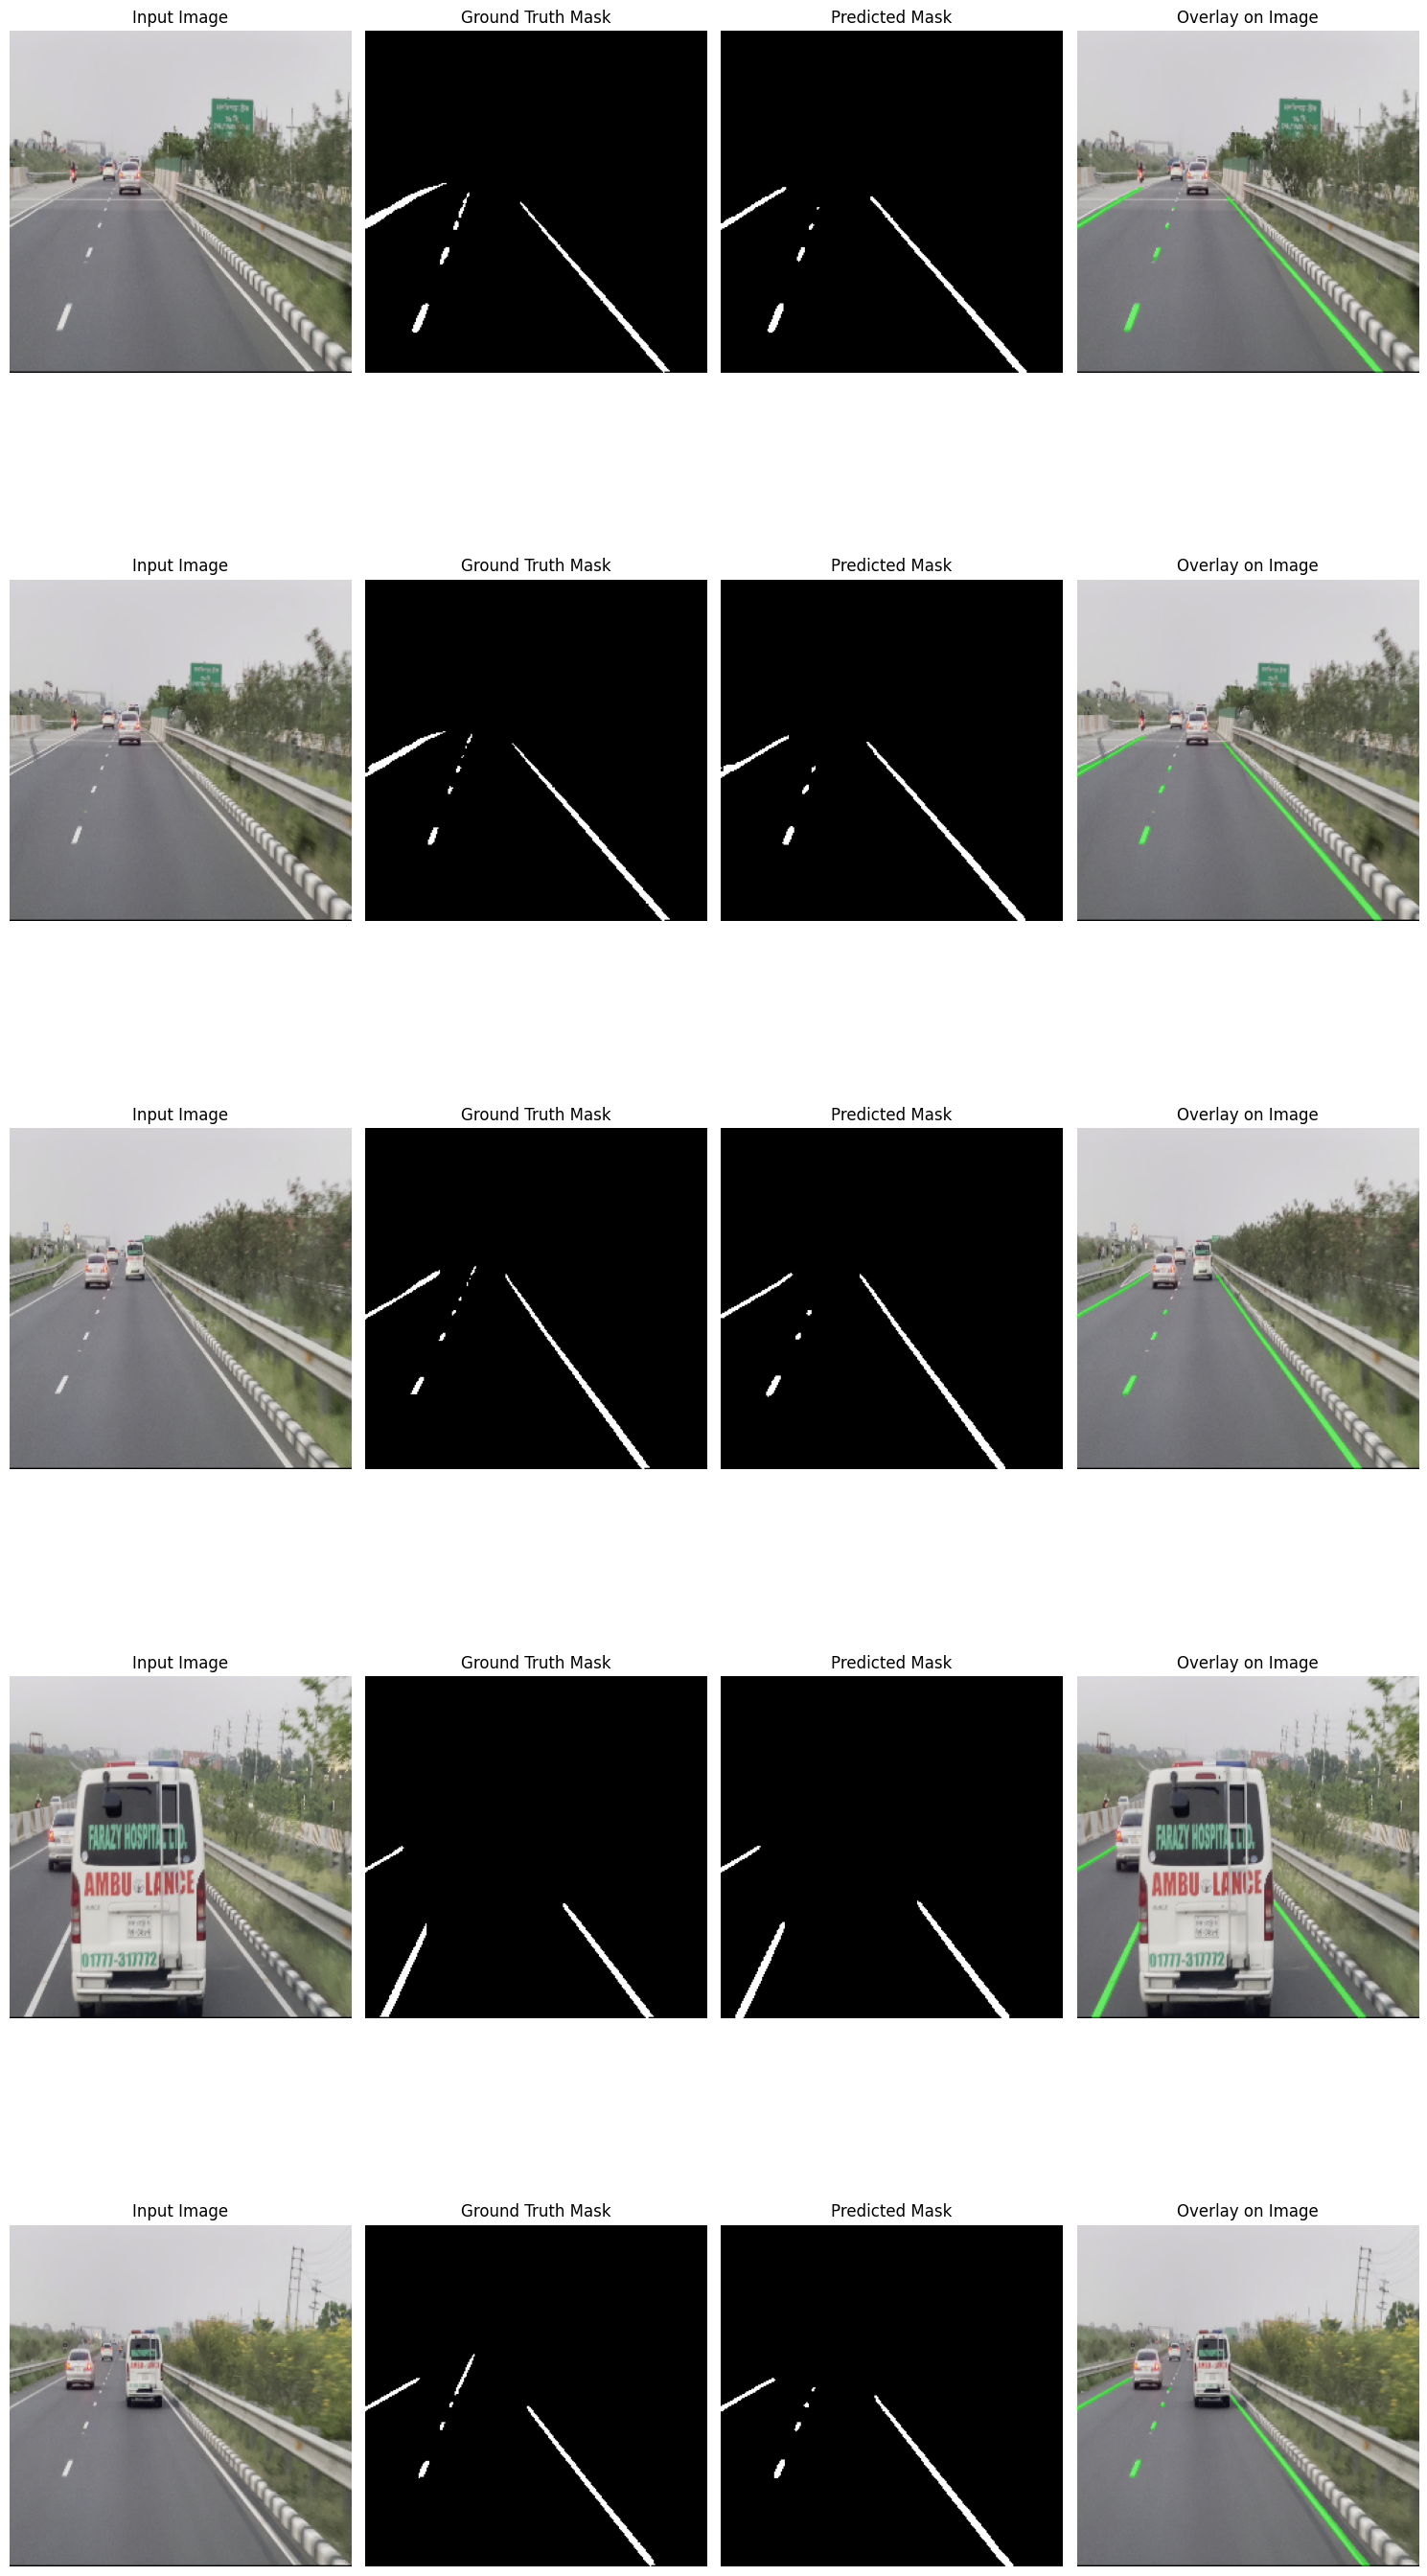

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import torch

def denormalize(image, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    """
    Denormalize a normalized image tensor back to its original format.
    :param image: Normalized image tensor (C, H, W).
    :param mean: Mean used for normalization.
    :param std: Standard deviation used for normalization.
    :return: Denormalized image as a NumPy array.
    """
    mean = np.array(mean).reshape(1, 1, 3)
    std = np.array(std).reshape(1, 1, 3)
    image = image.permute(1, 2, 0).cpu().numpy()  # Convert to (H, W, C)
    image = (image * std + mean) * 255.0  # Denormalize and scale to [0, 255]
    return np.clip(image, 0, 255).astype(np.uint8)  # Clip values to valid range

def overlay_mask_on_image(image, mask, color=(0, 255, 0), alpha=0.5):
    """
    Overlay a binary mask on an image with a specified color and transparency.
    :param image: Original image (H, W, C) in RGB format.
    :param mask: Binary mask (H, W) with values 0 or 1.
    :param color: Overlay color (default is green).
    :param alpha: Transparency of the overlay (default is 0.5).
    :return: Image with overlay.
    """
    overlay = image.copy()
    mask = mask.astype(bool)
    overlay[mask] = (overlay[mask] * (1 - alpha) + np.array(color) * alpha).astype(np.uint8)
    return overlay

def test_and_visualize(model, dataloader, device, num_images=5):
    """
    Test the model and visualize predictions.
    :param model: Trained model.
    :param dataloader: Dataloader for test data.
    :param device: Device (CPU or GPU).
    :param num_images: Number of images to visualize.
    """
    model.eval()
    plt.figure(figsize=(15, num_images * 6))
    with torch.no_grad():
        for idx, (images, masks) in enumerate(dataloader):
            if idx >= num_images:  # Limit number of images displayed
                break

            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            lane_segmentation_output = outputs[2][:, 0, :, :]  # Select the first channel for lane lines
            preds = (lane_segmentation_output > 0.5).float()  # Binarize predictions

            for i in range(images.size(0)):
                # Denormalize input image
                input_image = denormalize(images[i])

                ground_truth_mask = masks[i].cpu().numpy()
                predicted_mask = preds[i].cpu().numpy()

                # Overlay predicted mask on input image
                overlay_image = overlay_mask_on_image(input_image, predicted_mask)

                # Plot input image, ground truth mask, predicted mask, and overlay
                plt.subplot(num_images, 4, 4 * idx + 1)
                plt.imshow(input_image)
                plt.title("Input Image")
                plt.axis("off")

                plt.subplot(num_images, 4, 4 * idx + 2)
                plt.imshow(ground_truth_mask, cmap="gray")
                plt.title("Ground Truth Mask")
                plt.axis("off")

                plt.subplot(num_images, 4, 4 * idx + 3)
                plt.imshow(predicted_mask, cmap="gray")
                plt.title("Predicted Mask")
                plt.axis("off")

                plt.subplot(num_images, 4, 4 * idx + 4)
                plt.imshow(overlay_image)
                plt.title("Overlay on Image")
                plt.axis("off")

            # Stop after visualizing the required number of images
            if idx >= num_images - 1:
                break

    plt.tight_layout()
    plt.show()

# Load the saved model
model.load_state_dict(torch.load('/content/drive/MyDrive/path_to_model/yolop_lane_detection_final17.pt', map_location=device))
model = model.to(device)

# Test and visualize predictions
test_and_visualize(model, test_loader, device, num_images=5)


# Evaluation metrics

This section evaluates the performance of trained models on **training** and **testing datasets**. Metrics include:

- **IoU (Intersection over Union)**: Measures the overlap between predicted and ground truth masks.
- **Pixel Accuracy**: Fraction of correctly predicted pixels.
- **Precision**: Proportion of positive identifications that were correct.
- **Recall**: Proportion of actual positives identified correctly.
- **Loss**: Combined Binary Cross-Entropy (BCE) and Dice loss.

## Helper Functions
- `dice_loss`: Calculate Dice loss for segmentation.
- `combined_loss`: Combination of BCE and Dice loss.
- `calculate_metrics`: Calculate IoU and Pixel Accuracy.
- `evaluate_model`: Evaluate the model on a given dataset.

## Training Evaluation Metrics
- Evaluate the model on a subset of training data.
- Model: `best3`.

## Testing Evaluation Metrics
- Evaluate the model on the test dataset.
- Model: `yolop_lane_detection2`.


## Training evaluation metrics

**`model`** : **`yolop_lane_detection_final17`**







In [ ]:
import torch
from sklearn.metrics import precision_score, recall_score

def calculate_metrics(preds, masks):
    """
    Calculate IoU and Pixel Accuracy metrics.
    :param preds: Predicted binary masks.
    :param masks: Ground truth binary masks.
    :return: IoU and Pixel Accuracy.
    """
    intersection = (preds * masks).sum()  # Intersection of predicted and ground truth
    union = (preds + masks).clamp(0, 1).sum()  # Union of predicted and ground truth
    iou = intersection / union if union != 0 else 0  # Intersection over Union (IoU)
    pixel_accuracy = (preds == masks).float().mean()  # Pixel-wise accuracy
    return iou.item(), pixel_accuracy.item()

def evaluate_model(model, dataloader, loss_fn, device):
    """
    Evaluate the model on a given dataloader and calculate metrics.
    :param model: Trained model.
    :param dataloader: Dataloader for evaluation.
    :param loss_fn: Loss function used during training.
    :param device: Device (CPU or GPU).
    :return: Evaluation metrics (loss, IoU, Pixel Accuracy, Precision, Recall).
    """
    model.eval()
    total_loss = 0
    total_iou = 0
    total_pixel_acc = 0
    total_precision = 0
    total_recall = 0
    num_batches = len(dataloader)

    with torch.no_grad():
        for batch_idx, (images, masks) in enumerate(dataloader):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            lane_segmentation_output = outputs[2][:, 0, :, :]  # Select the first channel for lane lines

            # Calculate loss
            loss = loss_fn(lane_segmentation_output, masks)
            total_loss += loss.item()

            # Convert predictions to binary
            preds = (lane_segmentation_output > 0.5).float()

            # Metrics calculation
            iou, pixel_acc = calculate_metrics(preds, masks)
            total_iou += iou
            total_pixel_acc += pixel_acc

            # Flatten tensors for precision/recall calculation
            preds_flat = preds.view(-1).cpu().numpy()
            masks_flat = masks.view(-1).cpu().numpy()

            # Convert predictions to binary integers for sklearn
            preds_flat = (preds_flat > 0.5).astype(int)
            masks_flat = masks_flat.astype(int)

            # Precision and Recall
            total_precision += precision_score(masks_flat, preds_flat, zero_division=0)
            total_recall += recall_score(masks_flat, preds_flat, zero_division=0)

    # Average metrics
    avg_loss = total_loss / num_batches
    avg_iou = total_iou / num_batches
    avg_pixel_acc = total_pixel_acc / num_batches
    avg_precision = total_precision / num_batches
    avg_recall = total_recall / num_batches

    # Print metrics
    print(f"Loss: {avg_loss:.4f}")
    print(f"IoU: {avg_iou:.4f}")
    print(f"Pixel Accuracy: {avg_pixel_acc:.4f}")
    print(f"Precision: {avg_precision:.4f}")
    print(f"Recall: {avg_recall:.4f}")

    return avg_loss, avg_iou, avg_pixel_acc, avg_precision, avg_recall

# Load the saved model
model.load_state_dict(torch.load('/content/drive/MyDrive/path_to_model/yolop_lane_detection_final17.pt', map_location=device))
model = model.to(device)

# Define the loss function (same as used during training)
import torch.nn.functional as F

def dice_loss(preds, targets, smooth=1):
    """
    Dice Loss for binary segmentation.
    :param preds: Predicted logits (before applying sigmoid).
    :param targets: Ground truth binary masks.
    :param smooth: Smoothing factor to prevent division by zero.
    :return: Dice loss value.
    """
    preds = torch.sigmoid(preds)  # Convert logits to probabilities
    intersection = (preds * targets).sum(dim=(1, 2))  # Per-sample intersection
    union = preds.sum(dim=(1, 2)) + targets.sum(dim=(1, 2))  # Per-sample union
    dice = (2. * intersection + smooth) / (union + smooth)
    return 1 - dice.mean()  # Return Dice loss

def combined_loss(preds, targets):
    """
    Combined loss function: Binary Cross-Entropy + Dice Loss.
    :param preds: Predicted logits (before applying sigmoid).
    :param targets: Ground truth binary masks.
    :return: Combined loss value.
    """
    bce = F.binary_cross_entropy_with_logits(preds, targets)  # BCEWithLogitsLoss
    dice = dice_loss(preds, targets)  # Dice loss
    return bce + dice  # Combined loss

loss_fn = combined_loss  # Combined BCE + Dice loss

# Evaluate the model on the entire training dataset
evaluate_model(model, train_loader, loss_fn, device)  # No limit on batches

<ipython-input-13-19db21fdf80b>:81: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/content/drive/MyDrive/path_to_model/yolop_lane_detection

Loss: 1.8931
IoU: 0.7169
Pixel Accuracy: 0.9941
Precision: 0.6343
Recall: 0.8945


(1.8930813841900582,
 0.7169258046453282,
 0.9941451120174537,
 0.6342537147481269,
 0.8944789807722503)

## Testing evaluation metrics

**`model`** : **`yolop_lane_detection_final17`**

In [ ]:
import torch
from sklearn.metrics import precision_score, recall_score

def calculate_metrics(preds, masks):
    """
    Calculate IoU and Pixel Accuracy metrics.
    :param preds: Predicted binary masks.
    :param masks: Ground truth binary masks.
    :return: IoU and Pixel Accuracy.
    """
    intersection = (preds * masks).sum()  # Intersection of predicted and ground truth
    union = (preds + masks).clamp(0, 1).sum()  # Union of predicted and ground truth
    iou = intersection / union if union != 0 else 0  # Intersection over Union (IoU)
    pixel_accuracy = (preds == masks).float().mean()  # Pixel-wise accuracy
    return iou.item(), pixel_accuracy.item()

def evaluate_model(model, dataloader, loss_fn, device, max_batches=None):
    """
    Evaluate the model on a given dataloader and calculate metrics.
    :param model: Trained model.
    :param dataloader: Dataloader for evaluation.
    :param loss_fn: Loss function used during training.
    :param device: Device (CPU or GPU).
    :param max_batches: Limit the number of batches for evaluation (optional).
    :return: Evaluation metrics (loss, IoU, Pixel Accuracy, Precision, Recall).
    """
    model.eval()
    total_loss = 0
    total_iou = 0
    total_pixel_acc = 0
    total_precision = 0
    total_recall = 0
    num_batches = len(dataloader) if max_batches is None else min(max_batches, len(dataloader))

    with torch.no_grad():
        for batch_idx, (images, masks) in enumerate(dataloader):
            if max_batches is not None and batch_idx >= max_batches:
                break

            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            lane_segmentation_output = outputs[2][:, 0, :, :]  # Select the first channel for lane lines

            # Calculate loss
            loss = loss_fn(lane_segmentation_output, masks)
            total_loss += loss.item()

            # Convert predictions to binary
            preds = (lane_segmentation_output > 0.5).float()

            # Metrics calculation
            iou, pixel_acc = calculate_metrics(preds, masks)
            total_iou += iou
            total_pixel_acc += pixel_acc

            # Flatten tensors for precision/recall calculation
            preds_flat = preds.view(-1).cpu().numpy()
            masks_flat = masks.view(-1).cpu().numpy()

            # Convert predictions to binary integers for sklearn
            preds_flat = (preds_flat > 0.5).astype(int)
            masks_flat = masks_flat.astype(int)

            # Precision and Recall
            total_precision += precision_score(masks_flat, preds_flat, zero_division=0)
            total_recall += recall_score(masks_flat, preds_flat, zero_division=0)

    # Average metrics
    avg_loss = total_loss / num_batches
    avg_iou = total_iou / num_batches
    avg_pixel_acc = total_pixel_acc / num_batches
    avg_precision = total_precision / num_batches
    avg_recall = total_recall / num_batches

    # Print metrics
    print(f"Loss: {avg_loss:.4f}")
    print(f"IoU: {avg_iou:.4f}")
    print(f"Pixel Accuracy: {avg_pixel_acc:.4f}")
    print(f"Precision: {avg_precision:.4f}")
    print(f"Recall: {avg_recall:.4f}")

    return avg_loss, avg_iou, avg_pixel_acc, avg_precision, avg_recall

# Load the saved model
model.load_state_dict(torch.load('/content/drive/MyDrive/path_to_model/yolop_lane_detection_final17.pt', map_location=device))
model = model.to(device)

# Define the loss function (same as used during training)
import torch.nn.functional as F

def dice_loss(preds, targets, smooth=1):
    """
    Dice Loss for binary segmentation.
    :param preds: Predicted logits (before applying sigmoid).
    :param targets: Ground truth binary masks.
    :param smooth: Smoothing factor to prevent division by zero.
    :return: Dice loss value.
    """
    preds = torch.sigmoid(preds)  # Convert logits to probabilities
    intersection = (preds * targets).sum(dim=(1, 2))  # Per-sample intersection
    union = preds.sum(dim=(1, 2)) + targets.sum(dim=(1, 2))  # Per-sample union
    dice = (2. * intersection + smooth) / (union + smooth)
    return 1 - dice.mean()  # Return Dice loss

def combined_loss(preds, targets):
    """
    Combined loss function: Binary Cross-Entropy + Dice Loss.
    :param preds: Predicted logits (before applying sigmoid).
    :param targets: Ground truth binary masks.
    :return: Combined loss value.
    """
    bce = F.binary_cross_entropy_with_logits(preds, targets)  # BCEWithLogitsLoss
    dice = dice_loss(preds, targets)  # Dice loss
    return bce + dice  # Combined loss

loss_fn = combined_loss  # Combined BCE + Dice loss

# Evaluate the model on a subset of the training data
evaluate_model(model, test_loader, loss_fn, device)  # Limit to 50 batches


<ipython-input-15-a4f1a0a62056>:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/content/drive/MyDrive/path_to_model/yolop_lane_detection

Loss: 1.8839
IoU: 0.7558
Pixel Accuracy: 0.9934
Precision: 0.6786
Recall: 0.9138


(1.8838580533609552,
 0.7558364418603606,
 0.9933709613347458,
 0.6785689972605392,
 0.9137644474949282)

# Graph visualization

## Training & validation performance graph ( `YOLOP` )

In [ ]:
import matplotlib.pyplot as plt

results = [
  {
    "epoch": 1,
    "train_loss": 2.2334,
    "train_iou": 0.0089,
    "train_accuracy": 0.1437,
    "val_loss": 2.1958,
    "val_iou": 0.0127,
    "val_accuracy": 0.2451
  },
  {
    "epoch": 2,
    "train_loss": 2.2207,
    "train_iou": 0.0104,
    "train_accuracy": 0.1827,
    "val_loss": 2.2193,
    "val_iou": 0.0133,
    "val_accuracy": 0.1819
  },
  {
    "epoch": 3,
    "train_loss": 2.2111,
    "train_iou": 0.0107,
    "train_accuracy": 0.213,
    "val_loss": 2.2232,
    "val_iou": 0.012,
    "val_accuracy": 0.171
  },
  {
    "epoch": 4,
    "train_loss": 2.2013,
    "train_iou": 0.0112,
    "train_accuracy": 0.242,
    "val_loss": 2.2292,
    "val_iou": 0.0122,
    "val_accuracy": 0.1566
  },
  {
    "epoch": 5,
    "train_loss": 2.1904,
    "train_iou": 0.0115,
    "train_accuracy": 0.2713,
    "val_loss": 2.2079,
    "val_iou": 0.0131,
    "val_accuracy": 0.2123
  },
  {
    "epoch": 6,
    "train_loss": 2.1789,
    "train_iou": 0.0118,
    "train_accuracy": 0.3021,
    "val_loss": 2.2061,
    "val_iou": 0.0124,
    "val_accuracy": 0.2183
  },
  {
    "epoch": 7,
    "train_loss": 2.1671,
    "train_iou": 0.0122,
    "train_accuracy": 0.3342,
    "val_loss": 2.1885,
    "val_iou": 0.0136,
    "val_accuracy": 0.2715
  },
  {
    "epoch": 8,
    "train_loss": 2.1545,
    "train_iou": 0.0132,
    "train_accuracy": 0.3684,
    "val_loss": 2.1724,
    "val_iou": 0.0156,
    "val_accuracy": 0.3083
  },
  {
    "epoch": 9,
    "train_loss": 2.1413,
    "train_iou": 0.0141,
    "train_accuracy": 0.4027,
    "val_loss": 2.125,
    "val_iou": 0.016,
    "val_accuracy": 0.4318
  },
  {
    "epoch": 10,
    "train_loss": 2.1283,
    "train_iou": 0.0145,
    "train_accuracy": 0.4372,
    "val_loss": 2.0789,
    "val_iou": 0.017,
    "val_accuracy": 0.5533
  },
  {
    "epoch": 11,
    "train_loss": 2.1151,
    "train_iou": 0.0147,
    "train_accuracy": 0.4709,
    "val_loss": 2.101,
    "val_iou": 0.0182,
    "val_accuracy": 0.511
  },
  {
    "epoch": 12,
    "train_loss": 2.1014,
    "train_iou": 0.0166,
    "train_accuracy": 0.506,
    "val_loss": 2.0894,
    "val_iou": 0.0173,
    "val_accuracy": 0.5269
  },
  {
    "epoch": 13,
    "train_loss": 2.0884,
    "train_iou": 0.0168,
    "train_accuracy": 0.5382,
    "val_loss": 2.1243,
    "val_iou": 0.0158,
    "val_accuracy": 0.4324
  },
  {
    "epoch": 14,
    "train_loss": 2.075,
    "train_iou": 0.0187,
    "train_accuracy": 0.5717,
    "val_loss": 2.0664,
    "val_iou": 0.0204,
    "val_accuracy": 0.5755
  },
  {
    "epoch": 15,
    "train_loss": 2.063,
    "train_iou": 0.0191,
    "train_accuracy": 0.6013,
    "val_loss": 2.1124,
    "val_iou": 0.0171,
    "val_accuracy": 0.4618
  },
  {
    "epoch": 16,
    "train_loss": 2.0507,
    "train_iou": 0.021,
    "train_accuracy": 0.6317,
    "val_loss": 2.0545,
    "val_iou": 0.0227,
    "val_accuracy": 0.6156
  },
  {
    "epoch": 17,
    "train_loss": 2.039,
    "train_iou": 0.0222,
    "train_accuracy": 0.6601,
    "val_loss": 2.0218,
    "val_iou": 0.0309,
    "val_accuracy": 0.6991
  },
  {
    "epoch": 18,
    "train_loss": 2.0272,
    "train_iou": 0.0251,
    "train_accuracy": 0.6877,
    "val_loss": 2.0294,
    "val_iou": 0.0229,
    "val_accuracy": 0.6349
  },
  {
    "epoch": 19,
    "train_loss": 2.0164,
    "train_iou": 0.0268,
    "train_accuracy": 0.7136,
    "val_loss": 2.0285,
    "val_iou": 0.0238,
    "val_accuracy": 0.6658
  },
  {
    "epoch": 20,
    "train_loss": 2.0065,
    "train_iou": 0.0286,
    "train_accuracy": 0.738,
    "val_loss": 1.9669,
    "val_iou": 0.0508,
    "val_accuracy": 0.8183
  },
  {
    "epoch": 21,
    "train_loss": 1.997,
    "train_iou": 0.0298,
    "train_accuracy": 0.7592,
    "val_loss": 1.9552,
    "val_iou": 0.0627,
    "val_accuracy": 0.8494
  },
  {
    "epoch": 22,
    "train_loss": 1.9876,
    "train_iou": 0.0341,
    "train_accuracy": 0.7819,
    "val_loss": 1.9754,
    "val_iou": 0.0544,
    "val_accuracy": 0.7964
  },
  {
    "epoch": 23,
    "train_loss": 1.9789,
    "train_iou": 0.0377,
    "train_accuracy": 0.8018,
    "val_loss": 1.9516,
    "val_iou": 0.0648,
    "val_accuracy": 0.8631
  },
  {
    "epoch": 24,
    "train_loss": 1.9707,
    "train_iou": 0.0413,
    "train_accuracy": 0.8206,
    "val_loss": 1.9425,
    "val_iou": 0.0722,
    "val_accuracy": 0.8951
  },
  {
    "epoch": 25,
    "train_loss": 1.9634,
    "train_iou": 0.0446,
    "train_accuracy": 0.8363,
    "val_loss": 1.9493,
    "val_iou": 0.0673,
    "val_accuracy": 0.8638
  },
  {
    "epoch": 26,
    "train_loss": 1.9563,
    "train_iou": 0.051,
    "train_accuracy": 0.8541,
    "val_loss": 1.9873,
    "val_iou": 0.0384,
    "val_accuracy": 0.7609
  },
  {
    "epoch": 27,
    "train_loss": 1.9502,
    "train_iou": 0.0529,
    "train_accuracy": 0.8686,
    "val_loss": 1.9475,
    "val_iou": 0.0809,
    "val_accuracy": 0.8621
  },
  {
    "epoch": 28,
    "train_loss": 1.9445,
    "train_iou": 0.0555,
    "train_accuracy": 0.8802,
    "val_loss": 1.9542,
    "val_iou": 0.0609,
    "val_accuracy": 0.8436
  },
  {
    "epoch": 29,
    "train_loss": 1.9388,
    "train_iou": 0.0639,
    "train_accuracy": 0.8932,
    "val_loss": 1.9425,
    "val_iou": 0.0805,
    "val_accuracy": 0.8745
  },
  {
    "epoch": 30,
    "train_loss": 1.9334,
    "train_iou": 0.0742,
    "train_accuracy": 0.9054,
    "val_loss": 1.9296,
    "val_iou": 0.0859,
    "val_accuracy": 0.9187
  },
  {
    "epoch": 31,
    "train_loss": 1.9289,
    "train_iou": 0.0804,
    "train_accuracy": 0.9152,
    "val_loss": 1.9111,
    "val_iou": 0.1067,
    "val_accuracy": 0.9471
  },
  {
    "epoch": 32,
    "train_loss": 1.926,
    "train_iou": 0.0723,
    "train_accuracy": 0.9222,
    "val_loss": 1.9166,
    "val_iou": 0.1036,
    "val_accuracy": 0.9344
  },
  {
    "epoch": 33,
    "train_loss": 1.9212,
    "train_iou": 0.0922,
    "train_accuracy": 0.9327,
    "val_loss": 1.9155,
    "val_iou": 0.124,
    "val_accuracy": 0.9414
  },
  {
    "epoch": 34,
    "train_loss": 1.9172,
    "train_iou": 0.1116,
    "train_accuracy": 0.9417,
    "val_loss": 1.909,
    "val_iou": 0.1412,
    "val_accuracy": 0.9516
  },
  {
    "epoch": 35,
    "train_loss": 1.9138,
    "train_iou": 0.129,
    "train_accuracy": 0.9497,
    "val_loss": 1.9055,
    "val_iou": 0.1643,
    "val_accuracy": 0.9589
  },
  {
    "epoch": 36,
    "train_loss": 1.9108,
    "train_iou": 0.1442,
    "train_accuracy": 0.9559,
    "val_loss": 1.9032,
    "val_iou": 0.1841,
    "val_accuracy": 0.9655
  },
  {
    "epoch": 37,
    "train_loss": 1.9083,
    "train_iou": 0.1591,
    "train_accuracy": 0.9612,
    "val_loss": 1.9022,
    "val_iou": 0.1974,
    "val_accuracy": 0.968
  },
  {
    "epoch": 38,
    "train_loss": 1.9064,
    "train_iou": 0.1725,
    "train_accuracy": 0.965,
    "val_loss": 1.9026,
    "val_iou": 0.1879,
    "val_accuracy": 0.9663
  },
  {
    "epoch": 39,
    "train_loss": 1.9045,
    "train_iou": 0.1883,
    "train_accuracy": 0.9691,
    "val_loss": 1.899,
    "val_iou": 0.2074,
    "val_accuracy": 0.9745
  },
  {
    "epoch": 40,
    "train_loss": 1.9031,
    "train_iou": 0.2042,
    "train_accuracy": 0.9725,
    "val_loss": 1.8985,
    "val_iou": 0.2383,
    "val_accuracy": 0.9767
  },
  {
    "epoch": 41,
    "train_loss": 1.9018,
    "train_iou": 0.2174,
    "train_accuracy": 0.9753,
    "val_loss": 1.898,
    "val_iou": 0.236,
    "val_accuracy": 0.9783
  },
  {
    "epoch": 42,
    "train_loss": 1.9009,
    "train_iou": 0.2275,
    "train_accuracy": 0.9771,
    "val_loss": 1.8984,
    "val_iou": 0.2408,
    "val_accuracy": 0.9789
  },
  {
    "epoch": 43,
    "train_loss": 1.9002,
    "train_iou": 0.2339,
    "train_accuracy": 0.978,
    "val_loss": 1.8968,
    "val_iou": 0.2458,
    "val_accuracy": 0.9798
  },
  {
    "epoch": 44,
    "train_loss": 1.8998,
    "train_iou": 0.2386,
    "train_accuracy": 0.9792,
    "val_loss": 1.897,
    "val_iou": 0.241,
    "val_accuracy": 0.9799
  },
  {
    "epoch": 45,
    "train_loss": 1.8996,
    "train_iou": 0.2378,
    "train_accuracy": 0.9796,
    "val_loss": 1.8983,
    "val_iou": 0.2004,
    "val_accuracy": 0.9753
  },
  {
    "epoch": 46,
    "train_loss": 1.8995,
    "train_iou": 0.2409,
    "train_accuracy": 0.9798,
    "val_loss": 1.8965,
    "val_iou": 0.2376,
    "val_accuracy": 0.9806
  },
  {
    "epoch": 47,
    "train_loss": 1.8992,
    "train_iou": 0.2433,
    "train_accuracy": 0.9805,
    "val_loss": 1.8964,
    "val_iou": 0.2639,
    "val_accuracy": 0.9807
  },
  {
    "epoch": 48,
    "train_loss": 1.899,
    "train_iou": 0.2511,
    "train_accuracy": 0.9807,
    "val_loss": 1.895,
    "val_iou": 0.3053,
    "val_accuracy": 0.9842
  },
  {
    "epoch": 49,
    "train_loss": 1.8986,
    "train_iou": 0.2749,
    "train_accuracy": 0.9821,
    "val_loss": 1.8956,
    "val_iou": 0.2884,
    "val_accuracy": 0.9823
  },
  {
    "epoch": 50,
    "train_loss": 1.898,
    "train_iou": 0.2972,
    "train_accuracy": 0.9837,
    "val_loss": 1.8948,
    "val_iou": 0.3055,
    "val_accuracy": 0.9846
  },
  {
    "epoch": 51,
    "train_loss": 1.8977,
    "train_iou": 0.3032,
    "train_accuracy": 0.9841,
    "val_loss": 1.8946,
    "val_iou": 0.3279,
    "val_accuracy": 0.9847
  },
  {
    "epoch": 52,
    "train_loss": 1.8975,
    "train_iou": 0.3139,
    "train_accuracy": 0.9846,
    "val_loss": 1.8945,
    "val_iou": 0.3281,
    "val_accuracy": 0.9846
  },
  {
    "epoch": 53,
    "train_loss": 1.8973,
    "train_iou": 0.3277,
    "train_accuracy": 0.9848,
    "val_loss": 1.8944,
    "val_iou": 0.3401,
    "val_accuracy": 0.9849
  },
  {
    "epoch": 54,
    "train_loss": 1.8971,
    "train_iou": 0.338,
    "train_accuracy": 0.9849,
    "val_loss": 1.8943,
    "val_iou": 0.3441,
    "val_accuracy": 0.9852
  },
  {
    "epoch": 55,
    "train_loss": 1.8971,
    "train_iou": 0.3442,
    "train_accuracy": 0.9851,
    "val_loss": 1.8942,
    "val_iou": 0.3574,
    "val_accuracy": 0.9853
  },
  {
    "epoch": 56,
    "train_loss": 1.897,
    "train_iou": 0.3488,
    "train_accuracy": 0.9852,
    "val_loss": 1.8942,
    "val_iou": 0.354,
    "val_accuracy": 0.9852
  },
  {
    "epoch": 57,
    "train_loss": 1.8969,
    "train_iou": 0.3554,
    "train_accuracy": 0.9853,
    "val_loss": 1.8942,
    "val_iou": 0.357,
    "val_accuracy": 0.9856
  },
  {
    "epoch": 58,
    "train_loss": 1.8969,
    "train_iou": 0.3583,
    "train_accuracy": 0.9854,
    "val_loss": 1.8941,
    "val_iou": 0.3657,
    "val_accuracy": 0.9855
  },
  {
    "epoch": 59,
    "train_loss": 1.8969,
    "train_iou": 0.3655,
    "train_accuracy": 0.9855,
    "val_loss": 1.892,
    "val_iou": 0.4916,
    "val_accuracy": 0.9917
  },
  {
    "epoch": 60,
    "train_loss": 1.8952,
    "train_iou": 0.4775,
    "train_accuracy": 0.9901,
    "val_loss": 1.8914,
    "val_iou": 0.5576,
    "val_accuracy": 0.9925
  },
  {
    "epoch": 61,
    "train_loss": 1.8943,
    "train_iou": 0.5458,
    "train_accuracy": 0.9922,
    "val_loss": 1.8912,
    "val_iou": 0.585,
    "val_accuracy": 0.9928
  },
  {
    "epoch": 62,
    "train_loss": 1.8941,
    "train_iou": 0.579,
    "train_accuracy": 0.9927,
    "val_loss": 1.8912,
    "val_iou": 0.5856,
    "val_accuracy": 0.9929
  },
  {
    "epoch": 63,
    "train_loss": 1.8939,
    "train_iou": 0.5923,
    "train_accuracy": 0.9928,
    "val_loss": 1.891,
    "val_iou": 0.6129,
    "val_accuracy": 0.9931
  },
  {
    "epoch": 64,
    "train_loss": 1.8938,
    "train_iou": 0.6102,
    "train_accuracy": 0.9931,
    "val_loss": 1.8909,
    "val_iou": 0.6221,
    "val_accuracy": 0.9931
  },
  {
    "epoch": 65,
    "train_loss": 1.8938,
    "train_iou": 0.6179,
    "train_accuracy": 0.9931,
    "val_loss": 1.8909,
    "val_iou": 0.6297,
    "val_accuracy": 0.9933
  },
  {
    "epoch": 66,
    "train_loss": 1.8937,
    "train_iou": 0.6257,
    "train_accuracy": 0.9932,
    "val_loss": 1.891,
    "val_iou": 0.6312,
    "val_accuracy": 0.9935
  },
  {
    "epoch": 67,
    "train_loss": 1.8936,
    "train_iou": 0.6326,
    "train_accuracy": 0.9933,
    "val_loss": 1.8909,
    "val_iou": 0.6234,
    "val_accuracy": 0.9934
  },
  {
    "epoch": 68,
    "train_loss": 1.8937,
    "train_iou": 0.6333,
    "train_accuracy": 0.9933,
    "val_loss": 1.8908,
    "val_iou": 0.6385,
    "val_accuracy": 0.9934
  },
  {
    "epoch": 69,
    "train_loss": 1.8936,
    "train_iou": 0.6426,
    "train_accuracy": 0.9934,
    "val_loss": 1.8908,
    "val_iou": 0.6388,
    "val_accuracy": 0.9935
  },
  {
    "epoch": 70,
    "train_loss": 1.8935,
    "train_iou": 0.6484,
    "train_accuracy": 0.9934,
    "val_loss": 1.8908,
    "val_iou": 0.6406,
    "val_accuracy": 0.9935
  },
  {
    "epoch": 71,
    "train_loss": 1.8935,
    "train_iou": 0.653,
    "train_accuracy": 0.9935,
    "val_loss": 1.8908,
    "val_iou": 0.6147,
    "val_accuracy": 0.9932
  },
  {
    "epoch": 72,
    "train_loss": 1.8934,
    "train_iou": 0.6577,
    "train_accuracy": 0.9935,
    "val_loss": 1.8908,
    "val_iou": 0.6568,
    "val_accuracy": 0.9936
  },
  {
    "epoch": 73,
    "train_loss": 1.8934,
    "train_iou": 0.6595,
    "train_accuracy": 0.9936,
    "val_loss": 1.8907,
    "val_iou": 0.6517,
    "val_accuracy": 0.9935
  },
  {
    "epoch": 74,
    "train_loss": 1.8934,
    "train_iou": 0.6659,
    "train_accuracy": 0.9937,
    "val_loss": 1.8907,
    "val_iou": 0.6476,
    "val_accuracy": 0.9935
  },
  {
    "epoch": 75,
    "train_loss": 1.8933,
    "train_iou": 0.668,
    "train_accuracy": 0.9937,
    "val_loss": 1.8907,
    "val_iou": 0.6594,
    "val_accuracy": 0.9936
  },
  {
    "epoch": 76,
    "train_loss": 1.8934,
    "train_iou": 0.6697,
    "train_accuracy": 0.9937,
    "val_loss": 1.8907,
    "val_iou": 0.6337,
    "val_accuracy": 0.9931
  },
  {
    "epoch": 77,
    "train_loss": 1.8933,
    "train_iou": 0.6702,
    "train_accuracy": 0.9937,
    "val_loss": 1.8907,
    "val_iou": 0.6286,
    "val_accuracy": 0.9933
  },
  {
    "epoch": 78,
    "train_loss": 1.8934,
    "train_iou": 0.6711,
    "train_accuracy": 0.9937,
    "val_loss": 1.8908,
    "val_iou": 0.6512,
    "val_accuracy": 0.9935
  },
  {
    "epoch": 79,
    "train_loss": 1.8934,
    "train_iou": 0.6739,
    "train_accuracy": 0.9937,
    "val_loss": 1.8906,
    "val_iou": 0.6639,
    "val_accuracy": 0.9935
  },
  {
    "epoch": 80,
    "train_loss": 1.8933,
    "train_iou": 0.6772,
    "train_accuracy": 0.9938,
    "val_loss": 1.8907,
    "val_iou": 0.6378,
    "val_accuracy": 0.9932
  },
  {
    "epoch": 81,
    "train_loss": 1.8934,
    "train_iou": 0.6782,
    "train_accuracy": 0.9938,
    "val_loss": 1.8906,
    "val_iou": 0.6796,
    "val_accuracy": 0.9938
  },
  {
    "epoch": 82,
    "train_loss": 1.8933,
    "train_iou": 0.6835,
    "train_accuracy": 0.9938,
    "val_loss": 1.8906,
    "val_iou": 0.6692,
    "val_accuracy": 0.9937
  },
  {
    "epoch": 83,
    "train_loss": 1.8933,
    "train_iou": 0.6853,
    "train_accuracy": 0.9939,
    "val_loss": 1.8906,
    "val_iou": 0.6765,
    "val_accuracy": 0.9937
  },
  {
    "epoch": 84,
    "train_loss": 1.8932,
    "train_iou": 0.6894,
    "train_accuracy": 0.9939,
    "val_loss": 1.8906,
    "val_iou": 0.6736,
    "val_accuracy": 0.9938
  },
  {
    "epoch": 85,
    "train_loss": 1.8933,
    "train_iou": 0.692,
    "train_accuracy": 0.9939,
    "val_loss": 1.8905,
    "val_iou": 0.674,
    "val_accuracy": 0.9937
  },
  {
    "epoch": 86,
    "train_loss": 1.8933,
    "train_iou": 0.6896,
    "train_accuracy": 0.9939,
    "val_loss": 1.8906,
    "val_iou": 0.6584,
    "val_accuracy": 0.9936
  },
  {
    "epoch": 87,
    "train_loss": 1.8932,
    "train_iou": 0.695,
    "train_accuracy": 0.994,
    "val_loss": 1.8906,
    "val_iou": 0.658,
    "val_accuracy": 0.9936
  },
  {
    "epoch": 88,
    "train_loss": 1.8932,
    "train_iou": 0.6951,
    "train_accuracy": 0.9939,
    "val_loss": 1.8905,
    "val_iou": 0.661,
    "val_accuracy": 0.9936
  },
  {
    "epoch": 89,
    "train_loss": 1.8933,
    "train_iou": 0.6985,
    "train_accuracy": 0.994,
    "val_loss": 1.8905,
    "val_iou": 0.6681,
    "val_accuracy": 0.9936
  },
  {
    "epoch": 90,
    "train_loss": 1.8932,
    "train_iou": 0.6984,
    "train_accuracy": 0.994,
    "val_loss": 1.8907,
    "val_iou": 0.6578,
    "val_accuracy": 0.9938
  },
  {
    "epoch": 91,
    "train_loss": 1.8931,
    "train_iou": 0.7027,
    "train_accuracy": 0.994,
    "val_loss": 1.8905,
    "val_iou": 0.6859,
    "val_accuracy": 0.9938
  },
  {
    "epoch": 92,
    "train_loss": 1.8932,
    "train_iou": 0.6982,
    "train_accuracy": 0.994,
    "val_loss": 1.8905,
    "val_iou": 0.6634,
    "val_accuracy": 0.9935
  },
  {
    "epoch": 93,
    "train_loss": 1.8932,
    "train_iou": 0.7042,
    "train_accuracy": 0.9941,
    "val_loss": 1.8905,
    "val_iou": 0.6798,
    "val_accuracy": 0.9938
  },
  {
    "epoch": 94,
    "train_loss": 1.8932,
    "train_iou": 0.7009,
    "train_accuracy": 0.994,
    "val_loss": 1.8905,
    "val_iou": 0.6836,
    "val_accuracy": 0.9938
  },
  {
    "epoch": 95,
    "train_loss": 1.893,
    "train_iou": 0.7062,
    "train_accuracy": 0.9941,
    "val_loss": 1.8905,
    "val_iou": 0.6868,
    "val_accuracy": 0.994
  },
  {
    "epoch": 96,
    "train_loss": 1.8932,
    "train_iou": 0.7067,
    "train_accuracy": 0.9941,
    "val_loss": 1.8905,
    "val_iou": 0.678,
    "val_accuracy": 0.9938
  },
  {
    "epoch": 97,
    "train_loss": 1.8931,
    "train_iou": 0.7063,
    "train_accuracy": 0.9941,
    "val_loss": 1.8905,
    "val_iou": 0.6759,
    "val_accuracy": 0.9938
  },
  {
    "epoch": 98,
    "train_loss": 1.8931,
    "train_iou": 0.7092,
    "train_accuracy": 0.9941,
    "val_loss": 1.8905,
    "val_iou": 0.6775,
    "val_accuracy": 0.9937
  },
  {
    "epoch": 99,
    "train_loss": 1.8931,
    "train_iou": 0.7126,
    "train_accuracy": 0.9941,
    "val_loss": 1.8904,
    "val_iou": 0.6879,
    "val_accuracy": 0.9938
  },
  {
    "epoch": 100,
    "train_loss": 1.8931,
    "train_iou": 0.7116,
    "train_accuracy": 0.9941,
    "val_loss": 1.8904,
    "val_iou": 0.6879,
    "val_accuracy": 0.9938
  }
]


# Extract data from the results array
epochs = [entry['epoch'] for entry in results]
train_loss = [entry['train_loss'] for entry in results]
val_loss = [entry['val_loss'] for entry in results]
train_iou = [entry['train_iou'] for entry in results]
val_iou = [entry['val_iou'] for entry in results]

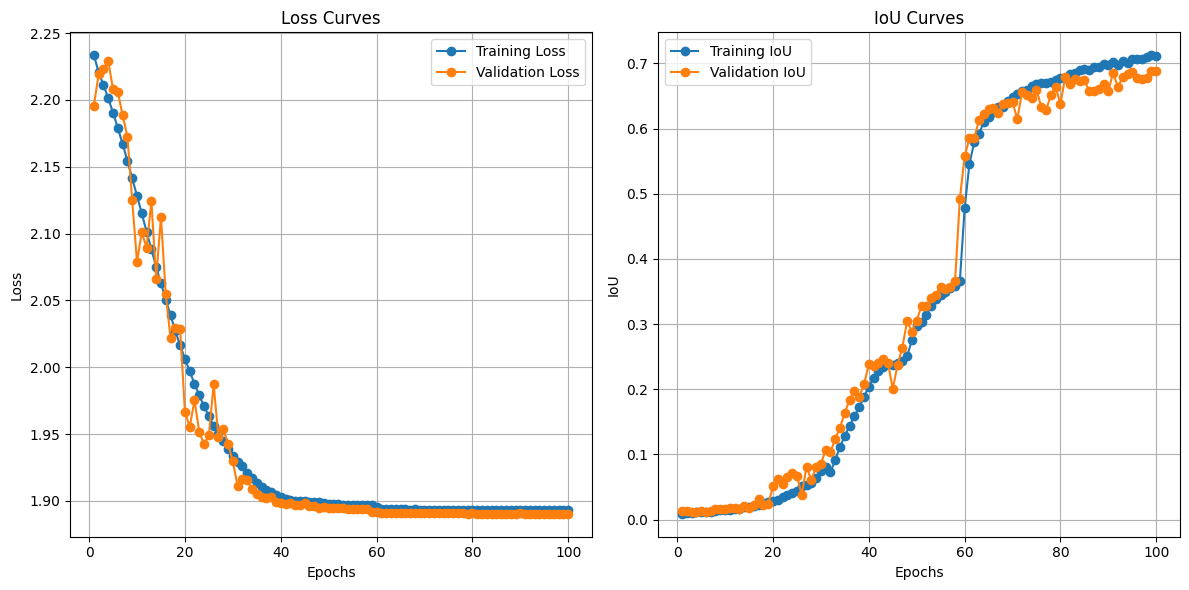

In [ ]:
# Plot the performance graphs
plt.figure(figsize=(12, 6))

# Loss Curves
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Training Loss', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()
plt.grid(True)

# IoU Curves
plt.subplot(1, 2, 2)
plt.plot(epochs, train_iou, label='Training IoU', marker='o')
plt.plot(epochs, val_iou, label='Validation IoU', marker='o')
plt.xlabel('Epochs')
plt.ylabel('IoU')
plt.title('IoU Curves')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()